# Task 3: Linear Regression

**AI & ML Internship**

In [7]:
# Imported ibraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from google.colab import files

In [8]:
#Load Dataset
df = pd.read_csv("Housing.csv")
print("Dataset loaded successfully!")
print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()

Dataset loaded successfully!
Dataset loaded successfully!
Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [9]:
# Inspect the dataset
print("Column names:")
print(df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Column names:
['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea', 'furnishingstatus']

Data types:
price                int64
area                 int64
bedrooms             int64
bathrooms            int64
stories              int64
mainroad            object
guestroom           object
basement            object
hotwaterheating     object
airconditioning     object
parking              int64
prefarea            object
furnishingstatus    object
dtype: object

Missing values:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

Duplicate rows: 0


In [10]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
price,545.0,NaN,NaN,NaN,4766729.247706,1870439.615657,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,NaN,NaN,NaN,5150.541284,2170.141023,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,NaN,NaN,NaN,2.965138,0.738064,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,NaN,NaN,NaN,1.286239,0.50247,1.0,1.0,1.0,2.0,4.0
stories,545.0,NaN,NaN,NaN,1.805505,0.867492,1.0,1.0,2.0,2.0,4.0
mainroad,545,2,yes,468,NaN,NaN,NaN,NaN,NaN,NaN,NaN
guestroom,545,2,no,448,NaN,NaN,NaN,NaN,NaN,NaN,NaN
basement,545,2,no,354,NaN,NaN,NaN,NaN,NaN,NaN,NaN
hotwaterheating,545,2,no,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
airconditioning,545,2,no,373,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
#Data Preprocessing
df = df.drop_duplicates().copy()
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())
categorical_cols = df.select_dtypes(exclude=np.number).columns
for col in categorical_cols:
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mode()[0])

print("Missing values after preprocessing:")
print(df.isnull().sum())

Missing values after preprocessing:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64


In [12]:
target = "price"
X = df.drop(columns=[target])
y = df[target]
X_encoded = pd.get_dummies(X, drop_first=True, dtype=int)
print("Original feature count:", X.shape[1])
print("Encoded feature count:", X_encoded.shape[1])
X_encoded.head()

Original feature count: 12
Encoded feature count: 13


,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,7420,4,2,3,2,1,0,0,0,1,1,0,0
1,8960,4,4,4,3,1,0,0,0,1,0,0,0
2,9960,3,2,2,2,1,0,1,0,0,1,1,0
3,7500,4,2,2,3,1,0,1,0,1,1,0,0
4,7420,4,1,2,2,1,1,1,0,1,0,0,0


In [13]:
# Simple Linear Regression
X_simple = df[["area"]]
y_simple = df["price"]

X_train_simple, X_test_simple, y_train_simple, y_test_simple = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

simple_model = LinearRegression()
simple_model.fit(X_train_simple, y_train_simple)
y_pred_simple = simple_model.predict(X_test_simple)
mae_simple = mean_absolute_error(y_test_simple, y_pred_simple)
mse_simple = mean_squared_error(y_test_simple, y_pred_simple)
r2_simple = r2_score(y_test_simple, y_pred_simple)

print("Simple Linear Regression Results")
print("-" * 35)
print(f"MAE: {mae_simple:,.2f}")
print(f"MSE: {mse_simple:,.2f}")
print(f"R² Score: {r2_simple:.4f}")
print(f"\nIntercept: {simple_model.intercept_:,.2f}")
print(f"Area coefficient: {simple_model.coef_[0]:,.2f}")

Simple Linear Regression Results
-----------------------------------
MAE: 1,474,748.13
MSE: 3,675,286,604,768.19
R² Score: 0.2729

Intercept: 2,512,254.26
Area coefficient: 425.73


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


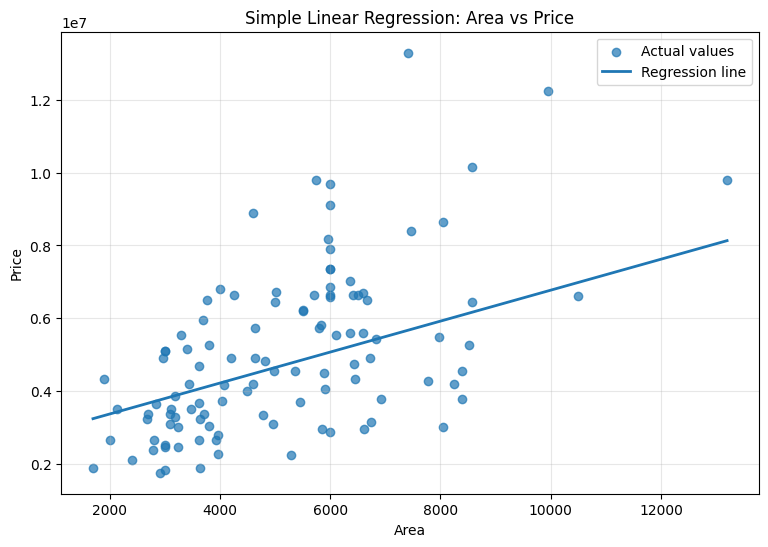

In [14]:
# Plot simple linear regression line
plt.figure(figsize=(9, 6))
plt.scatter(X_test_simple["area"], y_test_simple, alpha=0.7, label="Actual values")
sort_idx = np.argsort(X_test_simple["area"].values)
x_sorted = X_test_simple["area"].values[sort_idx]
y_line = simple_model.predict(x_sorted.reshape(-1, 1))

plt.plot(x_sorted, y_line, linewidth=2, label="Regression line")
plt.xlabel("Area")
plt.ylabel("Price")
plt.title("Simple Linear Regression: Area vs Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [15]:
# Multiple Linear Regression
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 436
Testing samples: 109


In [16]:
multiple_model = LinearRegression()
multiple_model.fit(X_train, y_train)
y_pred = multiple_model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Multiple Linear Regression Results")
print("-" * 40)
print(f"MAE: {mae:,.2f}")
print(f"MSE: {mse:,.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Intercept: {multiple_model.intercept_:,.2f}")


Multiple Linear Regression Results
----------------------------------------
MAE: 970,043.40
MSE: 1,754,318,687,330.66
R² Score: 0.6529
Intercept: 260,032.36


In [17]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})
comparison["Absolute Error"] = abs(
    comparison["Actual Price"] - comparison["Predicted Price"]
)
comparison.head(10)

,Actual Price,Predicted Price,Absolute Error
0,4060000,5.164654e+06,1.104654e+06
1,6650000,7.224722e+06,5.747223e+05
2,3710000,3.109863e+06,6.001368e+05
3,6440000,4.612075e+06,1.827925e+06
4,2800000,3.294646e+06,4.946463e+05
5,4900000,3.532275e+06,1.367725e+06
6,5250000,5.611775e+06,3.617746e+05
7,4543000,6.368146e+06,1.825146e+06
8,2450000,2.722857e+06,2.728570e+05
9,3353000,2.629406e+06,7.235944e+05


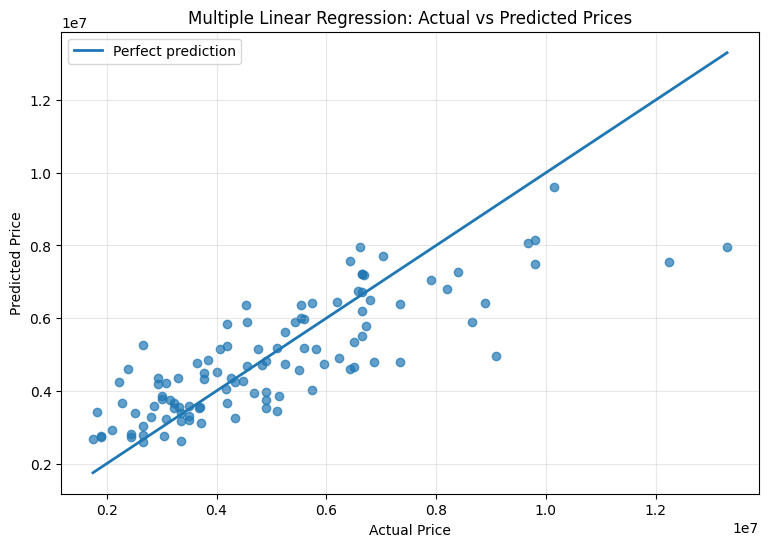

In [18]:
# Plot actual vs predicted prices
plt.figure(figsize=(9, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
min_value = min(y_test.min(), y_pred.min())
max_value = max(y_test.max(), y_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linewidth=2,
    label="Perfect prediction"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Multiple Linear Regression: Actual vs Predicted Prices")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [19]:
# Model Coefficients
coefficients = pd.DataFrame({
    "Feature": X_encoded.columns,
    "Coefficient": multiple_model.coef_
})
coefficients["Absolute Coefficient"] = coefficients["Coefficient"].abs()
coefficients = coefficients.sort_values("Absolute Coefficient", ascending=False)
coefficients


,Feature,Coefficient,Absolute Coefficient
2,bathrooms,1.094445e+06,1.094445e+06
9,airconditioning_yes,7.914267e+05,7.914267e+05
8,hotwaterheating_yes,6.846499e+05,6.846499e+05
10,prefarea_yes,6.298906e+05,6.298906e+05
12,furnishingstatus_unfurnished,-4.136451e+05,4.136451e+05
3,stories,4.074766e+05,4.074766e+05
7,basement_yes,3.902512e+05,3.902512e+05
5,mainroad_yes,3.679199e+05,3.679199e+05
6,guestroom_yes,2.316100e+05,2.316100e+05
4,parking,2.248419e+05,2.248419e+05


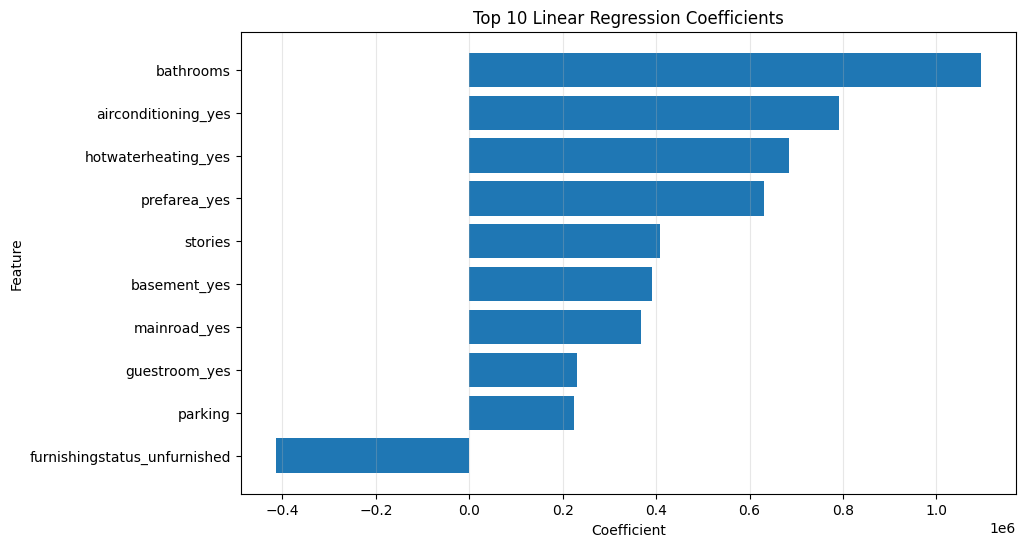

In [20]:
# Visualize
top_n = min(10, len(coefficients))
top_coefficients = coefficients.head(top_n).sort_values("Coefficient")

plt.figure(figsize=(10, 6))
plt.barh(top_coefficients["Feature"], top_coefficients["Coefficient"])
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title(f"Top {top_n} Linear Regression Coefficients")
plt.grid(True, axis="x", alpha=0.3)
plt.show()


In [21]:
# Final side-by-side metric comparison
results = pd.DataFrame({
    "Model": ["Simple Linear Regression", "Multiple Linear Regression"],
    "MAE": [mae_simple, mae],
    "MSE": [mse_simple, mse],
    "R2": [r2_simple, r2]
})
results

,Model,MAE,MSE,R2
0,Simple Linear Regression,1.474748e+06,3.675287e+12,0.272879
1,Multiple Linear Regression,9.700434e+05,1.754319e+12,0.652924
